In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("substancias_remineralizadoras.csv")

df.head()

,Autor,Ano,Substancia 1,Substancia 2,Substancia 3,Substância 4,Substancia 5,Concentração substancia 1,Concentração substancia 2,Concentração substancia 3,...,Area_de_superficie_polar,Teste_microdureza,Tempo Teste EDX (dias),Teste_EDX,Tempo microscopia (dias),Microscopia_eletrônica (micrometros) µm²,Microscopia_eletrônica (classificação),Mineraliza ou não,Doi,Justificativa
0,"Goldberg, Michel et al.",2011,colageno_tipo_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://pmc.ncbi.nlm.nih.gov/articles/PMC3360947/,NaN
1,"Goldberg, Michel et al.",2011,colageno_tipo_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,"Goldberg, Michel et al.",2011,hidroxiapatita,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,556.5,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,"Goldberg, Michel et al.",2011,glicoproteina_Da_dentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,"Goldberg, Michel et al.",2011,sialoproteina_ossea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [3]:
df.shape

(109, 57)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Autor                                     109 non-null    str    
 1   Ano                                       109 non-null    int64  
 2   Substancia 1                              109 non-null    str    
 3   Substancia 2                              35 non-null     str    
 4   Substancia 3                              8 non-null      str    
 5   Substância 4                              5 non-null      str    
 6   Substancia 5                              1 non-null      str    
 7   Concentração substancia 1                 24 non-null     str    
 8   Concentração substancia 2                 15 non-null     str    
 9   Concentração substancia 3                 8 non-null      str    
 10  Concentração substancia 4                 5 non-n

In [5]:
df.columns

Index(['Autor', 'Ano', 'Substancia 1', 'Substancia 2', 'Substancia 3',
       'Substância 4', 'Substancia 5', 'Concentração substancia 1',
       'Concentração substancia 2', 'Concentração substancia 3',
       'Concentração substancia 4', 'Concentração substancia 5',
       'Concentração g substancia 1', 'Porcentagem substancia 1',
       'Porcentagem substancia 2', 'Frequencia de aplicação/dia',
       'Tempo de aplicação (min)', 'Concentração Composição 1', 'Composição 1',
       'Concentração Composição 2', 'Composição 2',
       'Concentração Composição 3', 'Composição 3', 'Concentração comp 4',
       'Composição 4', 'Concentração comp 5', 'Composição 5',
       'Concentração comp 6', 'Composição 6', 'Composição 7', 'Composição 8',
       'Composição 9', 'Composição 10', 'Composição 11', 'Composição 12',
       'Composição 13', 'Composição 14', 'Composição 15', 'Composição 16',
       'Sequência de aminoácidos', 'Sequencia de aminoacidos 2',
       'Numero de aminoacidos', 'Formu

In [6]:
#conferir distribuição da variável alvo
df["Mineraliza ou não"].value_counts()

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64

In [7]:
df["Mineraliza ou não"].value_counts(normalize=True) * 100

Mineraliza ou não
1    66.055046
0    33.944954
Name: proportion, dtype: float64

In [8]:
# Quantidade de valores ausentes por coluna
valores_ausentes = df.isnull().sum().sort_values(ascending=False)

valores_ausentes

Justificativa                               109
Concentração substancia 5                   108
Sequencia de aminoacidos 2                  108
Composição 12                               108
Composição 13                               108
Composição 14                               108
Composição 16                               108
Composição 15                               108
Substancia 5                                108
Concentração comp 6                         107
Porcentagem substancia 2                    105
Composição 9                                105
Microscopia_eletrônica (micrometros) µm²    105
Concentração comp 5                         105
Composição 11                               105
Composição 10                               105
Substância 4                                104
Concentração substancia 4                   104
Frequencia de aplicação/dia                 104
pH                                          103
Area_de_superficie_polar                

In [9]:
# Tabela com quantidade e percentual de valores ausentes
missing = pd.DataFrame({
    "valores_ausentes": df.isnull().sum(),
    "percentual_ausente": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(by="percentual_ausente", ascending=False)

missing

,valores_ausentes,percentual_ausente
Justificativa,109,100.000000
Concentração substancia 5,108,99.082569
Sequencia de aminoacidos 2,108,99.082569
Composição 12,108,99.082569
Composição 13,108,99.082569
Composição 14,108,99.082569
Composição 16,108,99.082569
Composição 15,108,99.082569
Substancia 5,108,99.082569
Concentração comp 6,107,98.165138


## Análise inicial da variável alvo

A variável alvo utilizada foi "Mineraliza ou não", na qual:

- 1 representa substâncias com potencial/evidência de mineralização ou remineralização.
- 0 representa substâncias sem potencial/evidência suficiente.

A base possui 109 registros, sendo 72 classificados como positivos e 37 como negativos. Portanto, há um desbalanceamento moderado entre as classes, com predominância da classe positiva.

## Análise de valores ausentes

A análise de valores ausentes mostrou que muitas variáveis apresentam alto percentual de dados faltantes.
Várias variáveis e experimentais possuem mais de 70% de valores ausentes, o que limita a utilização direta no modelo.
Vou selecionar variáveis para o primeiro modelo vai ser feita de forma conservadora, priorizando colunas com maior preenchimento e evitando variáveis que possam causar vazamento de dados.

In [10]:
alvo = "Mineraliza ou não"

colunas_identificacao = [
    "Autor",
    "Ano",
    "Doi",
    "Justificativa"
]

colunas_experimentais = [
    "Teste_microdureza",
    "Tempo Teste EDX (dias)",
    "Teste_EDX",
    "Tempo microscopia (dias)",
    "Microscopia_eletrônica (micrometros) µm²",
    "Microscopia_eletrônica (classificação)"
]

In [11]:
colunas_candidatas = [
    col for col in df.columns
    if col not in colunas_identificacao
    and col not in colunas_experimentais
    and col != alvo
]

colunas_candidatas

['Substancia 1',
 'Substancia 2',
 'Substancia 3',
 'Substância 4',
 'Substancia 5',
 'Concentração substancia 1',
 'Concentração substancia 2',
 'Concentração substancia 3',
 'Concentração substancia 4',
 'Concentração substancia 5',
 'Concentração g substancia 1',
 'Porcentagem substancia 1',
 'Porcentagem substancia 2',
 'Frequencia de aplicação/dia',
 'Tempo de aplicação (min)',
 'Concentração Composição 1',
 'Composição 1',
 'Concentração Composição 2',
 'Composição 2',
 'Concentração Composição 3',
 'Composição 3',
 'Concentração comp 4',
 'Composição 4',
 'Concentração comp 5',
 'Composição 5',
 'Concentração comp 6',
 'Composição 6',
 'Composição 7',
 'Composição 8',
 'Composição 9',
 'Composição 10',
 'Composição 11',
 'Composição 12',
 'Composição 13',
 'Composição 14',
 'Composição 15',
 'Composição 16',
 'Sequência de aminoácidos',
 'Sequencia de aminoacidos 2',
 'Numero de aminoacidos',
 'Formula_molecular',
 'pH',
 'Peso_molecular (g/mol)',
 'Aceptores_de_ligacoes_de_hidr

In [12]:
missing_candidatas = missing.loc[colunas_candidatas].sort_values(
    by="percentual_ausente",
    ascending=False
)

missing_candidatas

,valores_ausentes,percentual_ausente
Substancia 5,108,99.082569
Concentração substancia 5,108,99.082569
Composição 16,108,99.082569
Sequencia de aminoacidos 2,108,99.082569
Composição 15,108,99.082569
Composição 14,108,99.082569
Composição 13,108,99.082569
Composição 12,108,99.082569
Concentração comp 6,107,98.165138
Concentração comp 5,105,96.330275


In [13]:
colunas_com_menos_ausentes = missing_candidatas[
    missing_candidatas["percentual_ausente"] <= 85
].index.tolist()

colunas_com_menos_ausentes

['Sequência de aminoácidos',
 'Concentração Composição 1',
 'Composição 5',
 'Concentração substancia 1',
 'Composição 4',
 'Substancia 2',
 'Composição 3',
 'Composição 2',
 'Composição 1',
 'Substancia 1']

In [14]:
df_modelo = df[colunas_com_menos_ausentes + [alvo]].copy()

df_modelo.head()

,Sequência de aminoácidos,Concentração Composição 1,Composição 5,Concentração substancia 1,Composição 4,Substancia 2,Composição 3,Composição 2,Composição 1,Substancia 1,Mineraliza ou não
0,MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKP...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_1,0
1,MMSFVQKGSWLLLALLHPTIILAQQEAVEGGCSHLGQSYADRDVWK...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_3,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hidroxiapatita,0
3,IPVPKGNFPKGMAREANTGGDDPKTTMSPSTSSVSSGNGSVTNSGI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,glicoproteina_Da_dentina,0
4,MKTALILLSILGMACAFSMKNLHRRVKIEDSEENGVFKYRPRYYLY...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sialoproteina_ossea,0


In [15]:
df_modelo.shape

(109, 11)

In [16]:
colunas_com_menos_ausentes

['Sequência de aminoácidos',
 'Concentração Composição 1',
 'Composição 5',
 'Concentração substancia 1',
 'Composição 4',
 'Substancia 2',
 'Composição 3',
 'Composição 2',
 'Composição 1',
 'Substancia 1']

In [17]:
alvo = "Mineraliza ou não"

features_modelo_1 = [
    'Sequência de aminoácidos',
    'Concentração Composição 1',
    'Composição 5',
    'Concentração substancia 1',
    'Composição 4',
    'Substancia 2',
    'Composição 3',
    'Composição 2',
    'Composição 1',
    'Substancia 1'
]

df_modelo = df[features_modelo_1 + [alvo]].copy()

df_modelo.head()

,Sequência de aminoácidos,Concentração Composição 1,Composição 5,Concentração substancia 1,Composição 4,Substancia 2,Composição 3,Composição 2,Composição 1,Substancia 1,Mineraliza ou não
0,MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKP...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_1,0
1,MMSFVQKGSWLLLALLHPTIILAQQEAVEGGCSHLGQSYADRDVWK...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_3,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hidroxiapatita,0
3,IPVPKGNFPKGMAREANTGGDDPKTTMSPSTSSVSSGNGSVTNSGI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,glicoproteina_Da_dentina,0
4,MKTALILLSILGMACAFSMKNLHRRVKIEDSEENGVFKYRPRYYLY...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sialoproteina_ossea,0


In [18]:
df_modelo.shape

(109, 11)

In [19]:
df_modelo.isnull().sum().sort_values(ascending=False)

Sequência de aminoácidos     92
Concentração Composição 1    90
Composição 5                 88
Concentração substancia 1    85
Composição 4                 82
Substancia 2                 74
Composição 3                 74
Composição 2                 61
Composição 1                 60
Substancia 1                  0
Mineraliza ou não             0
dtype: int64

In [20]:
df_modelo[features_modelo_1] = df_modelo[features_modelo_1].fillna("Não informado")

In [21]:
df_modelo.isnull().sum()

Sequência de aminoácidos     0
Concentração Composição 1    0
Composição 5                 0
Concentração substancia 1    0
Composição 4                 0
Substancia 2                 0
Composição 3                 0
Composição 2                 0
Composição 1                 0
Substancia 1                 0
Mineraliza ou não            0
dtype: int64

In [22]:
df_modelo[alvo].value_counts()

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64

In [23]:
df_modelo.head()

,Sequência de aminoácidos,Concentração Composição 1,Composição 5,Concentração substancia 1,Composição 4,Substancia 2,Composição 3,Composição 2,Composição 1,Substancia 1,Mineraliza ou não
0,MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKP...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,colageno_tipo_1,0
1,MMSFVQKGSWLLLALLHPTIILAQQEAVEGGCSHLGQSYADRDVWK...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,colageno_tipo_3,0
2,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,hidroxiapatita,0
3,IPVPKGNFPKGMAREANTGGDDPKTTMSPSTSSVSSGNGSVTNSGI...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,glicoproteina_Da_dentina,0
4,MKTALILLSILGMACAFSMKNLHRRVKIEDSEENGVFKYRPRYYLY...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,sialoproteina_ossea,0


## Seleção inicial de variáveis

Para o primeiro modelo exploratório, selecionei as colunas com percentual de valores ausentes menor ou igual a 85%, excluindo variáveis de identificação, referência bibliográfica e variáveis experimentais que poderiam causar vazamento de dados.
Como a maioria das variáveis selecionadas é categórica ou textual, os valores ausentes foram preenchidos com a categoria "Não informado". Essa estratégia adotei pra evitar a exclusão de amostras, considerando o tamanho reduzido da base.

In [24]:
X = df_modelo[features_modelo_1]
y = df_modelo[alvo]

print(X.shape)
print(y.shape)

(109, 10)
(109,)


In [25]:
y.value_counts()

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [27]:
preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_modelo_1)
    ]
)

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [30]:
from sklearn.dummy import DummyClassifier

In [31]:
dummy_model = DummyClassifier(strategy="most_frequent")

resultados_dummy = cross_validate(
    dummy_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

resultados_dummy

{'fit_time': array([0.00214767, 0.        , 0.        , 0.00188065, 0.00100207]),
 'score_time': array([0.00487351, 0.00687718, 0.00806093, 0.00533438, 0.00452542]),
 'test_accuracy': array([0.63636364, 0.63636364, 0.68181818, 0.68181818, 0.66666667]),
 'test_balanced_accuracy': array([0.5, 0.5, 0.5, 0.5, 0.5]),
 'test_precision': array([0.63636364, 0.63636364, 0.68181818, 0.68181818, 0.66666667]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_f1': array([0.77777778, 0.77777778, 0.81081081, 0.81081081, 0.8       ])}

In [32]:
pd.DataFrame(resultados_dummy).mean()

fit_time                  0.001006
score_time                0.005934
test_accuracy             0.660606
test_balanced_accuracy    0.500000
test_precision            0.660606
test_recall               1.000000
test_f1                   0.795435
dtype: float64

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
arvore_model = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", DecisionTreeClassifier(
        max_depth=3,
        random_state=42,
        class_weight="balanced"
    ))
])

In [35]:
resultados_arvore = cross_validate(
    arvore_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_arvore).mean()

fit_time                  0.007012
score_time                0.008916
test_accuracy             0.659740
test_balanced_accuracy    0.692381
test_precision            0.874286
test_recall               0.599048
test_f1                   0.677353
dtype: float64

In [36]:
#Comparando as duas baselines
resumo_baselines = pd.DataFrame({
    "Dummy Classifier": pd.DataFrame(resultados_dummy).mean(),
    "Árvore de Decisão": pd.DataFrame(resultados_arvore).mean()
})

resumo_baselines

,Dummy Classifier,Árvore de Decisão
fit_time,0.001006,0.007012
score_time,0.005934,0.008916
test_accuracy,0.660606,0.659740
test_balanced_accuracy,0.500000,0.692381
test_precision,0.660606,0.874286
test_recall,1.000000,0.599048
test_f1,0.795435,0.677353


## Modelos baseline

Criei dois modelos baseline para servir como referência de comparação com o Random Forest.
O primeiro foi um Dummy Classifier, que utiliza a estratégia de prever sempre a classe mais frequente. Esse modelo representa uma referência mínima de desempenho, permitindo verificar se modelos mais complexos realmente aprendem padrões além da distribuição majoritária da base.
O segundo modelo baseline foi uma Árvore de Decisão simples, configurada com profundidade máxima limitada. Essa comparação é relevante porque o Random Forest é composto por múltiplas árvores de decisão, permitindo avaliar se o modelo ensemble apresenta ganho em relação a uma árvore individual.

Devido ao tamanho reduzido do dataset, foi utilizada validação cruzada estratificada com 5 divisões, preservando a proporção entre as classes em cada fold.

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [38]:
resultados_random_forest = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_random_forest).mean()

fit_time                  0.091230
score_time                0.013782
test_accuracy             0.713853
test_balanced_accuracy    0.679643
test_precision            0.782353
test_recall               0.791429
test_f1                   0.785057
dtype: float64

In [39]:
resumo_modelos = pd.DataFrame({
    "Dummy Classifier": pd.DataFrame(resultados_dummy).mean(),
    "Árvore de Decisão": pd.DataFrame(resultados_arvore).mean(),
    "Random Forest": pd.DataFrame(resultados_random_forest).mean()
})

resumo_modelos

,Dummy Classifier,Árvore de Decisão,Random Forest
fit_time,0.001006,0.007012,0.091230
score_time,0.005934,0.008916,0.013782
test_accuracy,0.660606,0.659740,0.713853
test_balanced_accuracy,0.500000,0.692381,0.679643
test_precision,0.660606,0.874286,0.782353
test_recall,1.000000,0.599048,0.791429
test_f1,0.795435,0.677353,0.785057


## Interpretação dos modelos baseline

O Dummy Classifier apresentou acurácia próxima de 66%, resultado esperado devido à predominância da classe positiva na base. No entanto, sua balanced accuracy foi de 0.50, indicando ausência de capacidade real de discriminação entre as classes.
A Árvore de Decisão simples apresentou acurácia semelhante ao Dummy Classifier, porém obteve balanced accuracy superior. Isso indica que, apesar da limitação do dataset, o modelo conseguiu capturar algum padrão nas variáveis utilizadas, diferenciando melhor os compostos classificados como positivos e negativos.

Dessa forma, a Árvore de Decisão será utilizada como baseline supervisionada para comparação com o modelo Random Forest.

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# Predições com validação cruzada
y_pred_arvore = cross_val_predict(arvore_model, X, y, cv=cv)
y_pred_rf = cross_val_predict(random_forest_model, X, y, cv=cv)

print("Árvore de Decisão")
print(confusion_matrix(y, y_pred_arvore))
print(classification_report(y, y_pred_arvore))

print("Random Forest")
print(confusion_matrix(y, y_pred_rf))
print(classification_report(y, y_pred_rf))

Árvore de Decisão
[[29  8]
 [29 43]]
              precision    recall  f1-score   support

           0       0.50      0.78      0.61        37
           1       0.84      0.60      0.70        72

    accuracy                           0.66       109
   macro avg       0.67      0.69      0.65       109
weighted avg       0.73      0.66      0.67       109

Random Forest
[[21 16]
 [15 57]]
              precision    recall  f1-score   support

           0       0.58      0.57      0.58        37
           1       0.78      0.79      0.79        72

    accuracy                           0.72       109
   macro avg       0.68      0.68      0.68       109
weighted avg       0.71      0.72      0.71       109



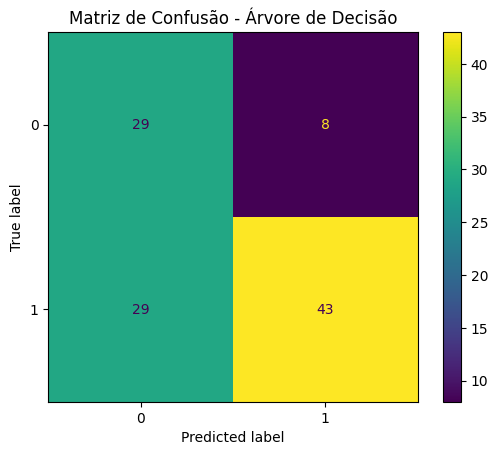

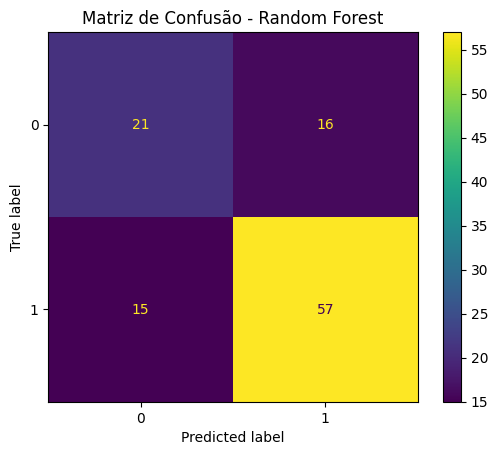

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y, y_pred_arvore)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

ConfusionMatrixDisplay.from_predictions(y, y_pred_rf)
plt.title("Matriz de Confusão - Random Forest")
plt.show()

## Comparação entre os modelos

O Random Forest apresentou desempenho superior ao Dummy Classifier, especialmente em acurácia e balanced accuracy, indicando que o modelo foi capaz de aprender padrões além da classe majoritária.

Em comparação com a Árvore de Decisão simples, o Random Forest apresentou maior acurácia, recall e F1-score. Porém, a Árvore de Decisão obteve balanced accuracy superior, sugerindo melhor equilíbrio entre as classes nesta configuração inicial.

Considerando o tamanho reduzido e a alta quantidade de valores ausentes na base, os resultados devem ser interpretados como preliminares e exploratórios. O objetivo principal desta etapa é avaliar a viabilidade do uso de modelos de Machine Learning como apoio à triagem inicial de compostos com potencial remineralizador.

## Interpretação da matriz de confusão

A Árvore de Decisão apresentou melhor desempenho na identificação da classe 0, correspondente aos compostos sem evidência de mineralização. No entanto, o modelo apresentou uma quantidade elevada de falsos negativos, classificando como não mineralizadores diversos compostos que pertenciam à classe positiva. O Random Forest, por outro lado, apresentou maior capacidade de identificação da classe positiva. O modelo classificou corretamente 57 dos 72 compostos mineralizadores, reduzindo a quantidade de falsos negativos em comparação com a Árvore de Decisão. Apesar disso, apresentou maior número de falsos positivos, classificando alguns compostos não mineralizadores como positivos.

Considerando o objetivo do projeto como uma etapa de triagem preliminar, o Random Forest é interessante por reduzir a chance de descartar compostos potencialmente promissores. Então, os resultados devem ser interpretados com cautela devido ao tamanho reduzido da base e à alta quantidade de valores ausentes.

In [42]:
random_forest_model.fit(X, y)

encoder = random_forest_model.named_steps["preprocessamento"].named_transformers_["cat"]
modelo_rf = random_forest_model.named_steps["modelo"]

nomes_features = encoder.get_feature_names_out(features_modelo_1)

importancias = pd.DataFrame({
    "feature": nomes_features,
    "importancia": modelo_rf.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias.head(20)

,feature,importancia
102,Substancia 2_Não informado,0.125144
72,Concentração substancia 1_Não informado,0.036352
215,Composição 1_Não informado,0.022943
66,Concentração substancia 1_3%,0.018097
245,Substancia 1_NaF,0.014812
305,Substancia 1_β-TCP_fosfato_tricálcico_beta,0.013835
117,Substancia 2_sistema_adesivo,0.013669
281,Substancia 1_peptideo_P11-4,0.013570
14,Sequência de aminoácidos_Não informado,0.012551
180,Composição 2_Não informado,0.011922


In [43]:
def identificar_coluna_original(feature):
    for coluna in sorted(features_modelo_1, key=len, reverse=True):
        if feature.startswith(coluna + "_"):
            return coluna
    return feature

importancias["coluna_original"] = importancias["feature"].apply(identificar_coluna_original)

importancia_por_coluna = (
    importancias
    .groupby("coluna_original")["importancia"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

importancia_por_coluna

,coluna_original,importancia
0,Substancia 1,0.333666
1,Substancia 2,0.179854
2,Composição 1,0.110338
3,Composição 2,0.081957
4,Concentração substancia 1,0.076135
5,Composição 3,0.058295
6,Sequência de aminoácidos,0.055297
7,Composição 4,0.044014
8,Concentração Composição 1,0.030333
9,Composição 5,0.030112


## Importância das variáveis no Random Forest

A análise de importância das variáveis indicou que as colunas mais relevantes para o modelo foram "Substancia 1", "Substancia 2", "Composição 1" e "Composição 2".
Esse resultado é coerente com o objetivo do projeto, já que o potencial de nucleação/remineralização pode estar diretamente relacionado à natureza química dos compostos e às combinações presentes nas formulações. Essa interpretação deve ser feita com cautela. Como algumas variáveis representam nomes de substâncias ou categorias textuais, o modelo pode estar aprendendo associações específicas presentes no dataset, e não necessariamente relações químicas generalizáveis. Dessa forma, a importância das variáveis deve ser entendida como uma evidência exploratória, e não como uma explicação causal definitiva.

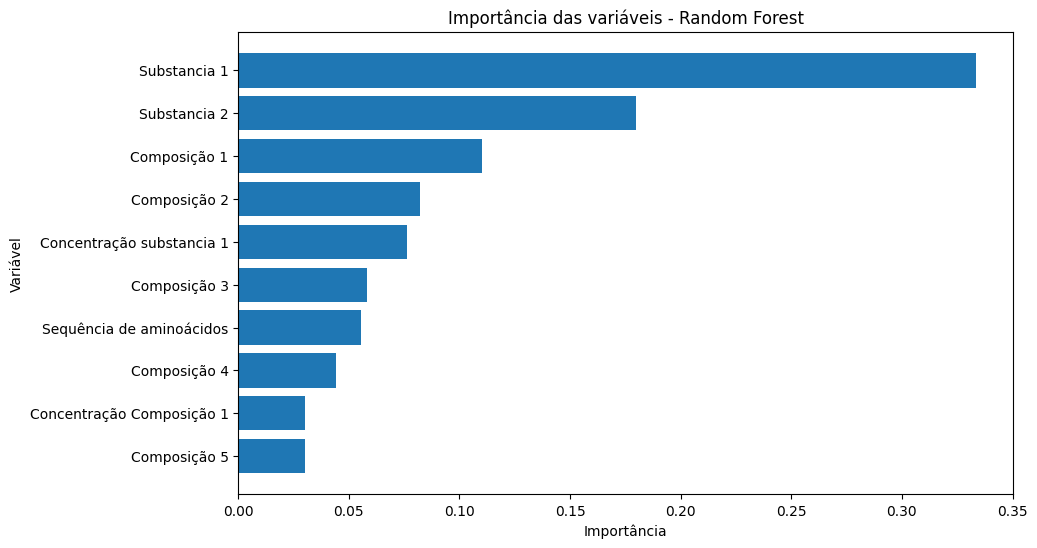

In [44]:

plt.figure(figsize=(10, 6))
plt.barh(importancia_por_coluna["coluna_original"], importancia_por_coluna["importancia"])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Importância das variáveis - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [45]:
import joblib
import os

os.makedirs("outputs", exist_ok=True)
random_forest_model.fit(X, y)
joblib.dump(random_forest_model, "outputs/random_forest_pipeline.pkl")

['outputs/random_forest_pipeline.pkl']

In [46]:
resumo_modelos.to_csv("outputs/resumo_modelos.csv", index=True)

In [47]:
predicoes_rf = df[["Autor", "Ano", "Substancia 1", "Substancia 2", "Mineraliza ou não"]].copy()

predicoes_rf["predicao_random_forest"] = y_pred_rf

predicoes_rf.to_csv("outputs/predicoes_random_forest.csv", index=False)

In [48]:
from sklearn.model_selection import cross_val_predict

probas_rf = cross_val_predict(
    random_forest_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

predicoes_rf["probabilidade_classe_0"] = probas_rf[:, 0]
predicoes_rf["probabilidade_classe_1"] = probas_rf[:, 1]

predicoes_rf.to_csv("outputs/predicoes_random_forest_com_probabilidades.csv", index=False)

In [49]:
importancia_por_coluna.to_csv("outputs/importancia_variaveis_random_forest.csv", index=False)

In [50]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

matriz_rf = confusion_matrix(y, y_pred_rf)

pd.DataFrame(
    matriz_rf,
    index=["Real 0", "Real 1"],
    columns=["Previsto 0", "Previsto 1"]
).to_csv("outputs/matriz_confusao_random_forest.csv")

relatorio_rf = classification_report(y, y_pred_rf, output_dict=True)

pd.DataFrame(relatorio_rf).transpose().to_csv("outputs/classification_report_random_forest.csv")

# Versão 2 — Imputação e otimização do Random Forest

Nesta etapa, será criada uma segunda versão do modelo, incluindo estratégias de imputação para valores ausentes, separação entre variáveis categóricas e numéricas, otimização de hiperparâmetros com Grid Search e posterior comparação com o Random Forest inicial.

In [51]:
alvo = "Mineraliza ou não"

colunas_identificacao = [
    "Autor",
    "Ano",
    "Doi",
    "Justificativa"
]

colunas_experimentais = [
    "Teste_microdureza",
    "Tempo Teste EDX (dias)",
    "Teste_EDX",
    "Tempo microscopia (dias)",
    "Microscopia_eletrônica (micrometros) µm²",
    "Microscopia_eletrônica (classificação)"
]

colunas_remover = colunas_identificacao + colunas_experimentais + [alvo]

colunas_candidatas_v2 = [
    col for col in df.columns
    if col not in colunas_remover
]

colunas_candidatas_v2

['Substancia 1',
 'Substancia 2',
 'Substancia 3',
 'Substância 4',
 'Substancia 5',
 'Concentração substancia 1',
 'Concentração substancia 2',
 'Concentração substancia 3',
 'Concentração substancia 4',
 'Concentração substancia 5',
 'Concentração g substancia 1',
 'Porcentagem substancia 1',
 'Porcentagem substancia 2',
 'Frequencia de aplicação/dia',
 'Tempo de aplicação (min)',
 'Concentração Composição 1',
 'Composição 1',
 'Concentração Composição 2',
 'Composição 2',
 'Concentração Composição 3',
 'Composição 3',
 'Concentração comp 4',
 'Composição 4',
 'Concentração comp 5',
 'Composição 5',
 'Concentração comp 6',
 'Composição 6',
 'Composição 7',
 'Composição 8',
 'Composição 9',
 'Composição 10',
 'Composição 11',
 'Composição 12',
 'Composição 13',
 'Composição 14',
 'Composição 15',
 'Composição 16',
 'Sequência de aminoácidos',
 'Sequencia de aminoacidos 2',
 'Numero de aminoacidos',
 'Formula_molecular',
 'pH',
 'Peso_molecular (g/mol)',
 'Aceptores_de_ligacoes_de_hidr

In [52]:
missing_v2 = pd.DataFrame({
    "valores_ausentes": df[colunas_candidatas_v2].isnull().sum(),
    "percentual_ausente": (df[colunas_candidatas_v2].isnull().sum() / len(df)) * 100
}).sort_values(by="percentual_ausente", ascending=False)

missing_v2

,valores_ausentes,percentual_ausente
Substancia 5,108,99.082569
Concentração substancia 5,108,99.082569
Composição 16,108,99.082569
Sequencia de aminoacidos 2,108,99.082569
Composição 15,108,99.082569
Composição 14,108,99.082569
Composição 13,108,99.082569
Composição 12,108,99.082569
Concentração comp 6,107,98.165138
Concentração comp 5,105,96.330275


In [53]:
colunas_v2 = missing_v2[
    missing_v2["percentual_ausente"] <= 85
].index.tolist()

colunas_v2

['Sequência de aminoácidos',
 'Concentração Composição 1',
 'Composição 5',
 'Concentração substancia 1',
 'Composição 4',
 'Substancia 2',
 'Composição 3',
 'Composição 2',
 'Composição 1',
 'Substancia 1']

In [54]:
df[colunas_v2].dtypes

Sequência de aminoácidos     str
Concentração Composição 1    str
Composição 5                 str
Concentração substancia 1    str
Composição 4                 str
Substancia 2                 str
Composição 3                 str
Composição 2                 str
Composição 1                 str
Substancia 1                 str
dtype: object

In [55]:
for col in colunas_v2:
    print("\nCOLUNA:", col)
    print(df[col].dropna().head(10).tolist())


COLUNA: Sequência de aminoácidos
['MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKPEVCLICICHNGTAVCDDVQCNEELDCPNPQRREGECCAFCPEEYVSPNSEDVGVEGPKGDPGPQGPRGPVGPPGRDGIPGQPGLPGPPGPPGPPGPPGLGGNFASQMSYGYDEKSAGVSVPGPMGPSGPRGLPGPPGAPGPQGFQGPPGEPGEPGGSGPMGPRGPPGPPGKNGDDGEAGKPGRPGERGPPGPQGARGLPGTAGLPGMKGHRGFSGLDGAKGDAGPAGPKGEPGSPGENGAPGQMGPRGLPGERGRPGPPGTAGARGNDGAVGAAGPPGPTGPTGPPGFPGAVGAKGEAGPQGARGSEGPQGVRGEPGPPGPAGAAGPAGNPGADGQPGAKGANGAPGIAGAPGFPGARGPSGPQGPSGPPGPKGNSGEPGAPGNKGDTGAKGEPGATGVQGPPGPAGEEGKRGARGEPGPSGLPGPPGERGGPGSRGFPGADGVAGPKGPSGERGAPGPAGPKGSPGEAGRPGEAGLPGAKGLTGSPGSPGPDGKTGPPGPAGQDGRPGPAGPPGARGQAGVMGFPGPKGTAGEPGKAGERGLPGPPGAVGPAGKDGEAGAQGAPGPAGPAGERGEQGPAGSPGFQGLPGPAGPPGEAGKPGEQGVPGDLGAPGPSGARGERGFPGERGVQGPPGPAGPRGNNGAPGNDGAKGDTGAPGAPGSQGAPGLQGMPGERGAAGLPGPKGDRGDAGPKGADGSPGKDGARGLTGPIGPPGPAGAPGDKGEAGPSGPPGPTGARGAPGDRGEAGPPGPAGFAGPPGADGQPGAKGEPGDTGVKGDAGPPGPAGPAGPPGPIGNVGAPGPKGPRGAAGPPGATGFPGAAGRVGPPGPSGNAGPPGPPGPVGKEGGKGPRGETGPAGRPGEVGPPGPPGPAGEKGSPGADGPAGSPGTPGPQGIAGQRGVVGLPGQRGERGFPGL

In [56]:
features_categoricas_v2 = [
    "Sequência de aminoácidos",
    "Composição 5",
    "Composição 4",
    "Substancia 2",
    "Composição 3",
    "Composição 2",
    "Composição 1",
    "Substancia 1"
]

features_numericas_v2 = [
    "Concentração Composição 1",
    "Concentração substancia 1"
]

In [57]:
df[features_numericas_v2].head(20)

,Concentração Composição 1,Concentração substancia 1
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [58]:
df[features_numericas_v2].dtypes

Concentração Composição 1    str
Concentração substancia 1    str
dtype: object

In [59]:
for col in features_numericas_v2:
    print("\nCOLUNA:", col)
    print("Valores preenchidos:", df[col].notna().sum())
    print(df[col].dropna().unique()[:30])


COLUNA: Concentração Composição 1
Valores preenchidos: 19
<StringArray>
[    '65%',     '45%',   '13.5g',  '0.498g',      '5%',     '10%',     '60%',
 '8mmol/L',       '1',   '0.12g',  '10mmol',      '51',      '44',  '85mol%',
    '42.8',  '0.5mol',     '95%',      '5g',   '43.3%']
Length: 19, dtype: str

COLUNA: Concentração substancia 1
Valores preenchidos: 24
<StringArray>
[      '153',      '52.6',      '7.5%',        '5%',      '2.5%',      '2.5g',
       '60%',   '0.263 g', '0.0145 g ',       '24%',       '30%',        '3%',
     '200ml',     '1.23%',        '2%']
Length: 15, dtype: str


In [60]:
df_v2 = df.copy()

In [61]:
def converter_para_numero(valor):
    if pd.isna(valor):
        return np.nan
    
    valor = str(valor).strip()
    valor = valor.replace(",", ".")
    valor = valor.replace("%", "")
    
    return pd.to_numeric(valor, errors="coerce")

In [62]:
for col in features_numericas_v2:
    df_v2[col] = df_v2[col].apply(converter_para_numero)

In [63]:
df_v2[features_numericas_v2].dtypes

Concentração Composição 1    float64
Concentração substancia 1    float64
dtype: object

In [64]:
df_v2[features_numericas_v2].describe()

,Concentração Composição 1,Concentração substancia 1
count,11.000000,19.000000
mean,42.009091,30.517368
std,27.986299,46.456603
min,1.000000,1.230000
25%,26.400000,3.000000
50%,44.000000,7.500000
75%,55.500000,27.000000
max,95.000000,153.000000


In [65]:
df_v2[features_numericas_v2].isnull().sum()

Concentração Composição 1    98
Concentração substancia 1    90
dtype: int64

In [66]:
features_v2 = features_categoricas_v2 + features_numericas_v2

X_v2 = df_v2[features_v2]
y_v2 = df_v2[alvo]

print(X_v2.shape)
print(y_v2.shape)

(109, 10)
(109,)


In [67]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [68]:
preprocessador_v2 = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Não informado")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), features_categoricas_v2),

        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median", add_indicator=True))
        ]), features_numericas_v2)
    ]
)

In [69]:
rf_v2 = Pipeline(steps=[
    ("preprocessamento", preprocessador_v2),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [70]:
resultados_rf_v2 = cross_validate(
    rf_v2,
    X_v2,
    y_v2,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_rf_v2).mean()

fit_time                  0.088603
score_time                0.017346
test_accuracy             0.668398
test_balanced_accuracy    0.600595
test_precision            0.721513
test_recall               0.819048
test_f1                   0.762796
dtype: float64

In [71]:
resumo_v2 = pd.DataFrame({
    "Random Forest inicial": pd.DataFrame(resultados_random_forest).mean(),
    "Random Forest V2 imputação": pd.DataFrame(resultados_rf_v2).mean()
})

resumo_v2

,Random Forest inicial,Random Forest V2 imputação
fit_time,0.091230,0.088603
score_time,0.013782,0.017346
test_accuracy,0.713853,0.668398
test_balanced_accuracy,0.679643,0.600595
test_precision,0.782353,0.721513
test_recall,0.791429,0.819048
test_f1,0.785057,0.762796


In [72]:
for col in features_numericas_v2:
    print("\nCOLUNA:", col)
    print("Valores preenchidos:", df[col].notna().sum())
    print(df[col].dropna().unique()[:30])


COLUNA: Concentração Composição 1
Valores preenchidos: 19
<StringArray>
[    '65%',     '45%',   '13.5g',  '0.498g',      '5%',     '10%',     '60%',
 '8mmol/L',       '1',   '0.12g',  '10mmol',      '51',      '44',  '85mol%',
    '42.8',  '0.5mol',     '95%',      '5g',   '43.3%']
Length: 19, dtype: str

COLUNA: Concentração substancia 1
Valores preenchidos: 24
<StringArray>
[      '153',      '52.6',      '7.5%',        '5%',      '2.5%',      '2.5g',
       '60%',   '0.263 g', '0.0145 g ',       '24%',       '30%',        '3%',
     '200ml',     '1.23%',        '2%']
Length: 15, dtype: str


# Teste versão 2 com Imputação

Testei uma versão com imputação numérica para variáveis de concentração, porém essas colunas apresentaram unidades heterogêneas, como porcentagem, massa e molaridade. Por esse motivo, a imputação por mediana não foi considerada adequada para o modelo principal. Apesar de aumentar o recall da classe positiva, a versão com imputação apresentou queda nas demais métricas.

In [73]:
features_categoricas_v2_corrigida = [
    "Sequência de aminoácidos",
    "Composição 5",
    "Composição 4",
    "Substancia 2",
    "Composição 3",
    "Composição 2",
    "Composição 1",
    "Substancia 1",
    "Concentração Composição 1",
    "Concentração substancia 1"
]

X_v2_corrigida = df[features_categoricas_v2_corrigida]
y_v2_corrigida = df[alvo]

In [74]:
preprocessador_v2_corrigida = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Não informado")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), features_categoricas_v2_corrigida)
    ]
)

In [75]:
rf_v2_corrigida = Pipeline(steps=[
    ("preprocessamento", preprocessador_v2_corrigida),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [76]:
resultados_rf_v2_corrigida = cross_validate(
    rf_v2_corrigida,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_rf_v2_corrigida).mean()

fit_time                  0.088295
score_time                0.014905
test_accuracy             0.687013
test_balanced_accuracy    0.644405
test_precision            0.760220
test_recall               0.792381
test_f1                   0.768210
dtype: float64

In [77]:
resumo_v2_corrigida = pd.DataFrame({
    "Random Forest inicial": pd.DataFrame(resultados_random_forest).mean(),
    "RF V2 imputação numérica": pd.DataFrame(resultados_rf_v2).mean(),
    "RF V2 corrigida categórica": pd.DataFrame(resultados_rf_v2_corrigida).mean()
})

resumo_v2_corrigida

,Random Forest inicial,RF V2 imputação numérica,RF V2 corrigida categórica
fit_time,0.091230,0.088603,0.088295
score_time,0.013782,0.017346,0.014905
test_accuracy,0.713853,0.668398,0.687013
test_balanced_accuracy,0.679643,0.600595,0.644405
test_precision,0.782353,0.721513,0.760220
test_recall,0.791429,0.819048,0.792381
test_f1,0.785057,0.762796,0.768210


# Grid Search — Otimização de hiperparâmetros

Nesta etapa, será realizada a otimização de hiperparâmetros do Random Forest utilizando Grid Search. O objetivo é verificar se ajustes nos parâmetros do modelo melhoram o desempenho em relação às versões anteriores.

In [78]:
from sklearn.model_selection import GridSearchCV

In [79]:
param_grid_rf = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 3, 5, 10],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__class_weight": ["balanced", None]
}

In [80]:
grid_rf = GridSearchCV(
    estimator=rf_v2_corrigida,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_rf.fit(X_v2_corrigida, y_v2_corrigida)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__class_weight': ['balanced', None], 'modelo__max_depth': [None, 3, ...], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbos

In [81]:
grid_rf.best_params_

{'modelo__class_weight': 'balanced',
 'modelo__max_depth': 3,
 'modelo__min_samples_leaf': 2,
 'modelo__min_samples_split': 2,
 'modelo__n_estimators': 200}

In [82]:
grid_rf.best_score_

np.float64(0.7401190476190476)

In [83]:
melhor_rf_grid = grid_rf.best_estimator_

In [84]:
resultados_rf_grid = cross_validate(
    melhor_rf_grid,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_rf_grid).mean()

fit_time                  0.167050
score_time                0.021281
test_accuracy             0.696537
test_balanced_accuracy    0.740119
test_precision            0.915065
test_recall               0.612381
test_f1                   0.719021
dtype: float64

In [85]:
resumo_grid = pd.DataFrame({
    "Random Forest inicial": pd.DataFrame(resultados_random_forest).mean(),
    "RF V2 imputação numérica": pd.DataFrame(resultados_rf_v2).mean(),
    "RF V2 corrigida categórica": pd.DataFrame(resultados_rf_v2_corrigida).mean(),
    "RF Grid Search": pd.DataFrame(resultados_rf_grid).mean()
})

resumo_grid

,Random Forest inicial,RF V2 imputação numérica,RF V2 corrigida categórica,RF Grid Search
fit_time,0.091230,0.088603,0.088295,0.167050
score_time,0.013782,0.017346,0.014905,0.021281
test_accuracy,0.713853,0.668398,0.687013,0.696537
test_balanced_accuracy,0.679643,0.600595,0.644405,0.740119
test_precision,0.782353,0.721513,0.760220,0.915065
test_recall,0.791429,0.819048,0.792381,0.612381
test_f1,0.785057,0.762796,0.768210,0.719021


In [86]:
grid_rf.best_params_

{'modelo__class_weight': 'balanced',
 'modelo__max_depth': 3,
 'modelo__min_samples_leaf': 2,
 'modelo__min_samples_split': 2,
 'modelo__n_estimators': 200}

In [87]:
resumo_grid

,Random Forest inicial,RF V2 imputação numérica,RF V2 corrigida categórica,RF Grid Search
fit_time,0.091230,0.088603,0.088295,0.167050
score_time,0.013782,0.017346,0.014905,0.021281
test_accuracy,0.713853,0.668398,0.687013,0.696537
test_balanced_accuracy,0.679643,0.600595,0.644405,0.740119
test_precision,0.782353,0.721513,0.760220,0.915065
test_recall,0.791429,0.819048,0.792381,0.612381
test_f1,0.785057,0.762796,0.768210,0.719021


In [88]:
grid_rf_recall = GridSearchCV(
    estimator=rf_v2_corrigida,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

grid_rf_recall.fit(X_v2_corrigida, y_v2_corrigida)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__class_weight': ['balanced', None], 'modelo__max_depth': [None, 3, ...], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the hi

In [89]:
grid_rf_recall.best_params_

{'modelo__class_weight': None,
 'modelo__max_depth': None,
 'modelo__min_samples_leaf': 2,
 'modelo__min_samples_split': 2,
 'modelo__n_estimators': 100}

In [90]:
grid_rf_recall.best_score_

np.float64(1.0)

In [91]:
melhor_rf_grid_recall = grid_rf_recall.best_estimator_

In [92]:
resultados_rf_grid_recall = cross_validate(
    melhor_rf_grid_recall,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_rf_grid_recall).mean()

fit_time                  0.083780
score_time                0.013987
test_accuracy             0.660606
test_balanced_accuracy    0.500000
test_precision            0.660606
test_recall               1.000000
test_f1                   0.795435
dtype: float64

In [93]:
resumo_grid_completo = pd.DataFrame({
    "Random Forest inicial": pd.DataFrame(resultados_random_forest).mean(),
    "RF V2 imputação numérica": pd.DataFrame(resultados_rf_v2).mean(),
    "RF V2 corrigida categórica": pd.DataFrame(resultados_rf_v2_corrigida).mean(),
    "RF Grid balanced_accuracy": pd.DataFrame(resultados_rf_grid).mean(),
    "RF Grid recall": pd.DataFrame(resultados_rf_grid_recall).mean()
})

resumo_grid_completo

,Random Forest inicial,RF V2 imputação numérica,RF V2 corrigida categórica,RF Grid balanced_accuracy,RF Grid recall
fit_time,0.091230,0.088603,0.088295,0.167050,0.083780
score_time,0.013782,0.017346,0.014905,0.021281,0.013987
test_accuracy,0.713853,0.668398,0.687013,0.696537,0.660606
test_balanced_accuracy,0.679643,0.600595,0.644405,0.740119,0.500000
test_precision,0.782353,0.721513,0.760220,0.915065,0.660606
test_recall,0.791429,0.819048,0.792381,0.612381,1.000000
test_f1,0.785057,0.762796,0.768210,0.719021,0.795435


# Modelos Essenciais

Aqui passei a olhar especialmente para o primeiro modelo de RF, e o modelo com Grid "RF Grid balanced_accuracy".

In [94]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [95]:
# Predições do RF Grid balanced_accuracy
y_pred_grid_balanced = cross_val_predict(
    melhor_rf_grid,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv
)

print("RF Grid balanced_accuracy")
print(confusion_matrix(y_v2_corrigida, y_pred_grid_balanced))
print(classification_report(y_v2_corrigida, y_pred_grid_balanced))

RF Grid balanced_accuracy
[[32  5]
 [28 44]]
              precision    recall  f1-score   support

           0       0.53      0.86      0.66        37
           1       0.90      0.61      0.73        72

    accuracy                           0.70       109
   macro avg       0.72      0.74      0.69       109
weighted avg       0.77      0.70      0.70       109



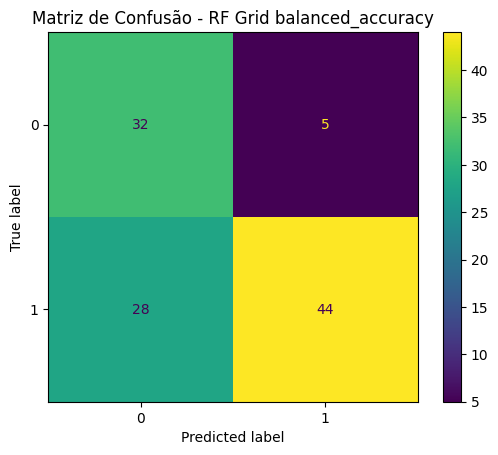

In [96]:
ConfusionMatrixDisplay.from_predictions(y_v2_corrigida, y_pred_grid_balanced)
plt.title("Matriz de Confusão - RF Grid balanced_accuracy")
plt.show()

O Grid Search otimizado por recall apresentou recall igual a 1.0, porém sua balanced accuracy foi igual a 0.50, comportamento equivalente ao Dummy Classifier. Isso indica que o modelo passou a prever praticamente todos os registros como pertencentes à classe positiva, não sendo adequado como modelo final.

O modelo otimizado por balanced accuracy apresentou melhor equilíbrio entre as classes e maior precisão, porém reduziu o recall da classe positiva. Dessa forma, a escolha entre o Random Forest inicial e o Random Forest otimizado por balanced accuracy depende do objetivo da triagem: priorizar a identificação de compostos promissores ou priorizar maior confiança nas predições positivas.

# Curva ROC

Nesta etapa, foi plotada a curva ROC para avaliar a capacidade dos modelos em separar as classes positiva e negativa a partir das probabilidades previstas.

In [97]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

In [98]:
probas_rf_inicial = cross_val_predict(
    random_forest_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

auc_rf_inicial = roc_auc_score(y, probas_rf_inicial[:, 1])

auc_rf_inicial

0.7687687687687689

In [99]:
probas_rf_grid_balanced = cross_val_predict(
    melhor_rf_grid,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv,
    method="predict_proba"
)

auc_rf_grid_balanced = roc_auc_score(y_v2_corrigida, probas_rf_grid_balanced[:, 1])

auc_rf_grid_balanced

0.7308558558558559

<Figure size 800x600 with 0 Axes>

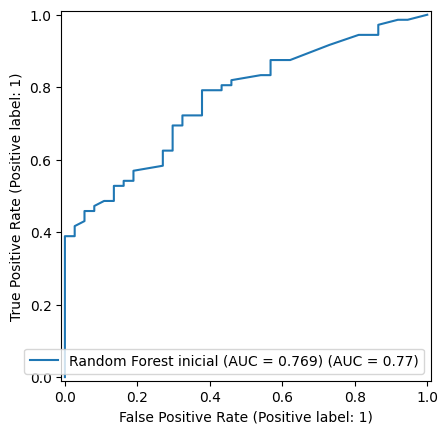

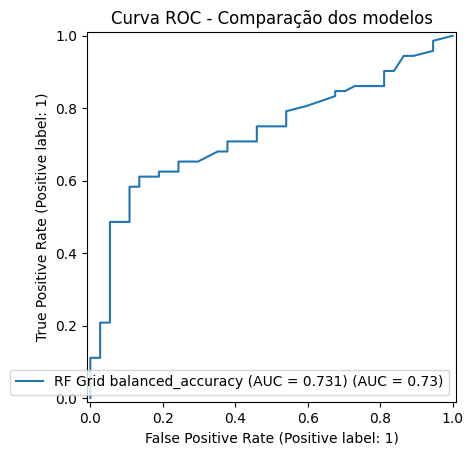

In [100]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y,
    probas_rf_inicial[:, 1],
    name=f"Random Forest inicial (AUC = {auc_rf_inicial:.3f})"
)

RocCurveDisplay.from_predictions(
    y_v2_corrigida,
    probas_rf_grid_balanced[:, 1],
    name=f"RF Grid balanced_accuracy (AUC = {auc_rf_grid_balanced:.3f})"
)

plt.title("Curva ROC - Comparação dos modelos")
plt.show()

## Interpretação da curva ROC

A curva ROC foi utilizada para avaliar a capacidade dos modelos em separar os compostos classificados como mineralizadores e não mineralizadores a partir das probabilidades previstas.

Foram comparados o Random Forest inicial e o Random Forest otimizado por Grid Search com foco em balanced accuracy. Essa comparação permite observar não apenas as classes previstas diretamente, mas também o comportamento probabilístico dos modelos.

Os resultados devem ser interpretados com cautela devido ao tamanho reduzido do dataset e à alta quantidade de valores ausentes. A curva ROC, neste contexto, atua como uma métrica complementar às demais métricas já analisadas, como balanced accuracy, precision, recall, F1-score e matriz de confusão.

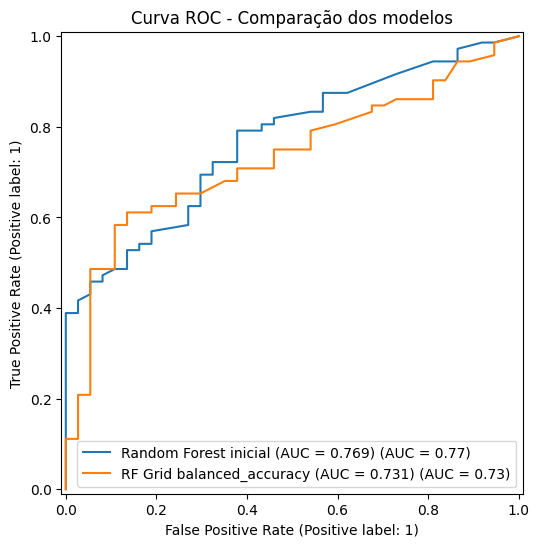

In [101]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y,
    probas_rf_inicial[:, 1],
    name=f"Random Forest inicial (AUC = {auc_rf_inicial:.3f})",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_v2_corrigida,
    probas_rf_grid_balanced[:, 1],
    name=f"RF Grid balanced_accuracy (AUC = {auc_rf_grid_balanced:.3f})",
    ax=ax
)

plt.title("Curva ROC - Comparação dos modelos")
plt.show()

## Interpretação da curva ROC

A curva ROC foi utilizada como métrica complementar para avaliar a capacidade dos modelos em separar as classes a partir das probabilidades previstas.

O Random Forest inicial apresentou AUC de aproximadamente 0,769, enquanto o modelo otimizado por Grid Search com balanced accuracy apresentou AUC de aproximadamente 0,731. Isso indica que, em termos probabilísticos, o Random Forest inicial apresentou melhor capacidade de separação entre compostos mineralizadores e não mineralizadores.

Apesar do modelo otimizado apresentar maior balanced accuracy e maior precision, ele reduziu o recall da classe positiva. Dessa forma, considerando o objetivo de triagem preliminar, o Random Forest inicial permanece como uma alternativa interessante por apresentar melhor recall, F1-score e AUC.

# PCA — Redução de dimensionalidade mantendo 90% da variância

Nesta etapa, foi aplicado PCA após o pré-processamento das variáveis categóricas, mantendo 90% da variância explicada. O objetivo é verificar se a redução de dimensionalidade melhora ou prejudica o desempenho do Random Forest.

In [102]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

In [103]:
try:
    onehot_dense = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_dense = OneHotEncoder(handle_unknown="ignore", sparse=False)

In [104]:
preprocessador_pca = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Não informado")),
            ("onehot", onehot_dense)
        ]), features_categoricas_v2_corrigida)
    ],
    sparse_threshold=0
)

In [105]:
rf_com_pca = Pipeline(steps=[
    ("preprocessamento", preprocessador_pca),
    ("pca", PCA(n_components=0.90, random_state=42)),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [106]:
resultados_rf_pca = cross_validate(
    rf_com_pca,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_rf_pca).mean()

fit_time                  0.101488
score_time                0.016421
test_accuracy             0.741558
test_balanced_accuracy    0.692976
test_precision            0.778319
test_recall               0.846667
test_f1                   0.809524
dtype: float64

In [107]:
resumo_final_sem_roc = pd.DataFrame({
    "Random Forest inicial": pd.DataFrame(resultados_random_forest).mean(),
    "RF Grid balanced_accuracy": pd.DataFrame(resultados_rf_grid).mean(),
    "RF com PCA 90%": pd.DataFrame(resultados_rf_pca).mean()
})

resumo_final_sem_roc

,Random Forest inicial,RF Grid balanced_accuracy,RF com PCA 90%
fit_time,0.091230,0.167050,0.101488
score_time,0.013782,0.021281,0.016421
test_accuracy,0.713853,0.696537,0.741558
test_balanced_accuracy,0.679643,0.740119,0.692976
test_precision,0.782353,0.915065,0.778319
test_recall,0.791429,0.612381,0.846667
test_f1,0.785057,0.719021,0.809524


In [108]:
rf_com_pca.fit(X_v2_corrigida, y_v2_corrigida)

pca_model = rf_com_pca.named_steps["pca"]

print("Número de componentes mantidos:", pca_model.n_components_)
print("Variância explicada acumulada:", pca_model.explained_variance_ratio_.sum())

Número de componentes mantidos: 60
Variância explicada acumulada: 0.9005049179901276


Random Forest com PCA 90%
[[20 17]
 [11 61]]
              precision    recall  f1-score   support

           0       0.65      0.54      0.59        37
           1       0.78      0.85      0.81        72

    accuracy                           0.74       109
   macro avg       0.71      0.69      0.70       109
weighted avg       0.74      0.74      0.74       109



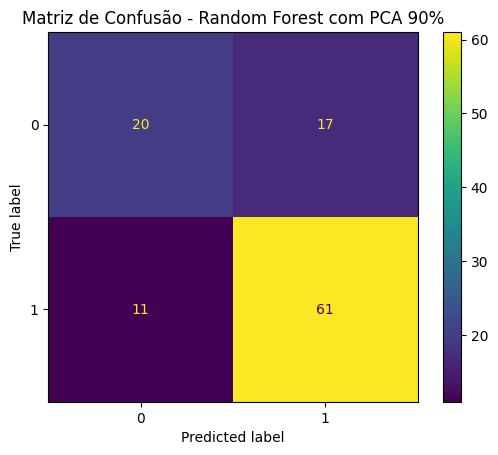

In [109]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_pca = cross_val_predict(
    rf_com_pca,
    X_v2_corrigida,
    y_v2_corrigida,
    cv=cv
)

print("Random Forest com PCA 90%")
print(confusion_matrix(y_v2_corrigida, y_pred_pca))
print(classification_report(y_v2_corrigida, y_pred_pca))

ConfusionMatrixDisplay.from_predictions(y_v2_corrigida, y_pred_pca)
plt.title("Matriz de Confusão - Random Forest com PCA 90%")
plt.show()

## Interpretação do PCA

A aplicação de PCA mantendo 90% da variância apresentou resultado positivo em relação ao Random Forest inicial. O modelo com PCA obteve maior acurácia, maior recall e maior F1-score, indicando melhor desempenho geral para a identificação de compostos classificados como mineralizadores.

Embora o modelo otimizado por Grid Search tenha apresentado maior balanced accuracy e maior precision, ele reduziu consideravelmente o recall da classe positiva. Como o objetivo do projeto é uma triagem preliminar, na qual é importante evitar o descarte de compostos potencialmente promissores, o Random Forest com PCA 90% mostrou-se uma alternativa interessante.

Ainda assim, os resultados devem ser interpretados com cautela devido ao tamanho reduzido da base, à alta quantidade de valores ausentes e à heterogeneidade dos dados extraídos da literatura.

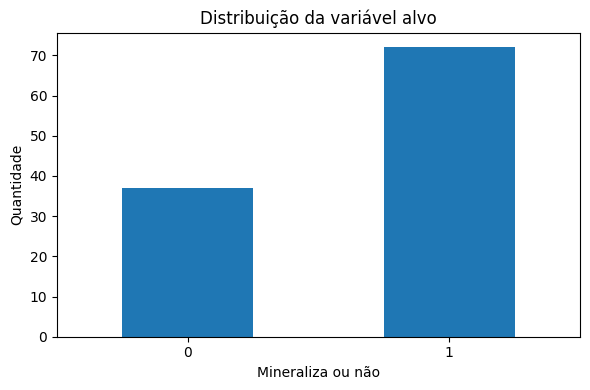

In [111]:
import os

os.makedirs("outputs/graficos", exist_ok=True)

plt.figure(figsize=(6, 4))
df["Mineraliza ou não"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da variável alvo")
plt.xlabel("Mineraliza ou não")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/graficos/distribuicao_variavel_alvo.png", dpi=300)
plt.show()
#Mostra quantos compostos mineralizam e quantos não mineralizam.

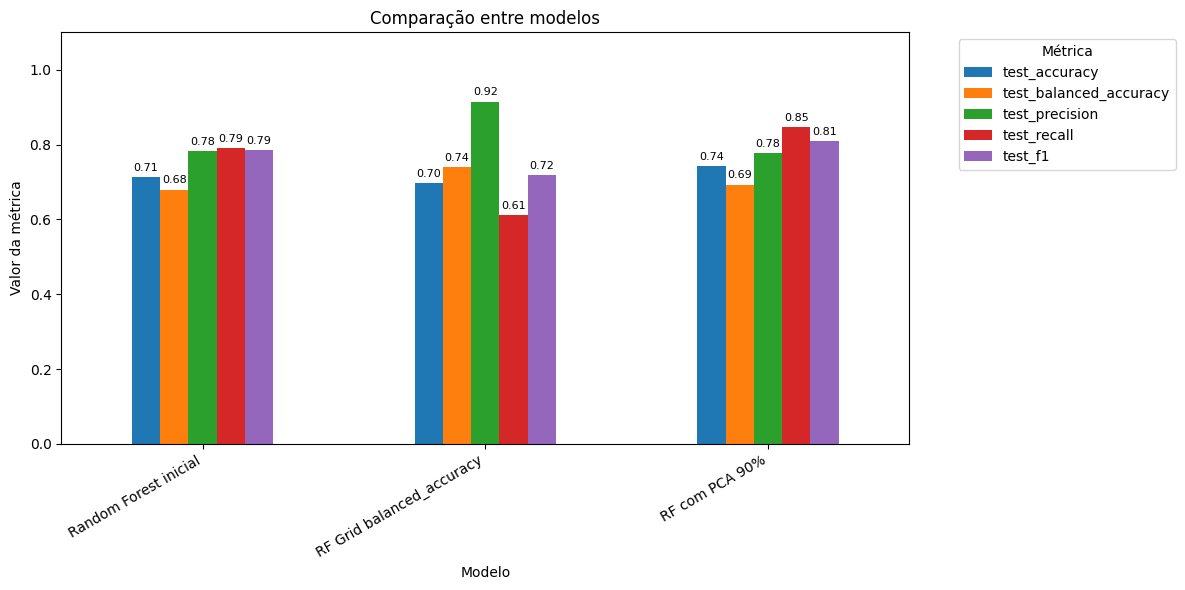

In [117]:
#Esse é um dos gráficos mais importantes para os superiores.
metricas_principais = resumo_final_sem_roc.loc[
    ["test_accuracy", "test_balanced_accuracy", "test_precision", "test_recall", "test_f1"]
]

ax = metricas_principais.T.plot(kind="bar", figsize=(12, 6))

plt.title("Comparação entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor da métrica")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.10)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        label_type="edge",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.savefig("outputs/graficos/comparacao_modelos.png", dpi=300)
plt.show()

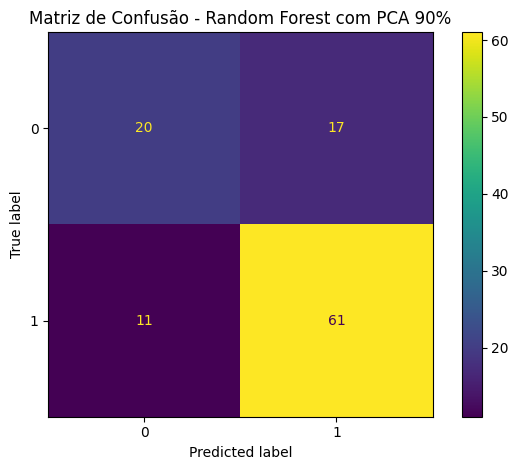

In [114]:
#Esse ajuda a explicar os erros do modelo.
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_v2_corrigida, y_pred_pca)
plt.title("Matriz de Confusão - Random Forest com PCA 90%")
plt.tight_layout()
plt.savefig("outputs/graficos/matriz_confusao_rf_pca_90.png", dpi=300)
plt.show()

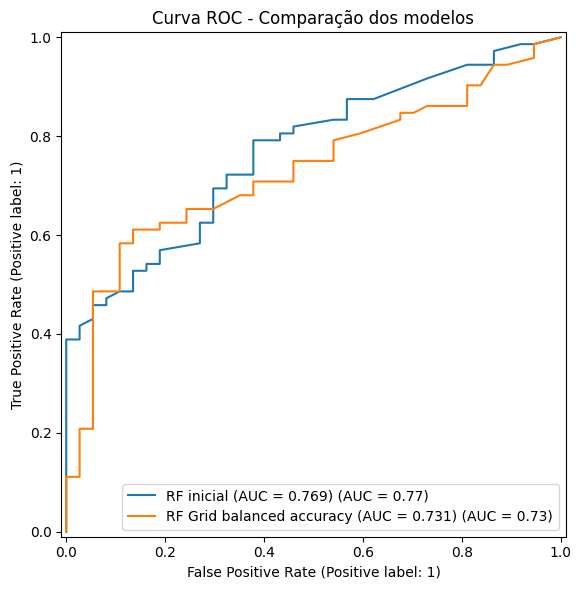

In [115]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y,
    probas_rf_inicial[:, 1],
    name=f"RF inicial (AUC = {auc_rf_inicial:.3f})",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_v2_corrigida,
    probas_rf_grid_balanced[:, 1],
    name=f"RF Grid balanced accuracy (AUC = {auc_rf_grid_balanced:.3f})",
    ax=ax
)

plt.title("Curva ROC - Comparação dos modelos")
plt.tight_layout()
plt.savefig("outputs/graficos/curva_roc_modelos.png", dpi=300)
plt.show()

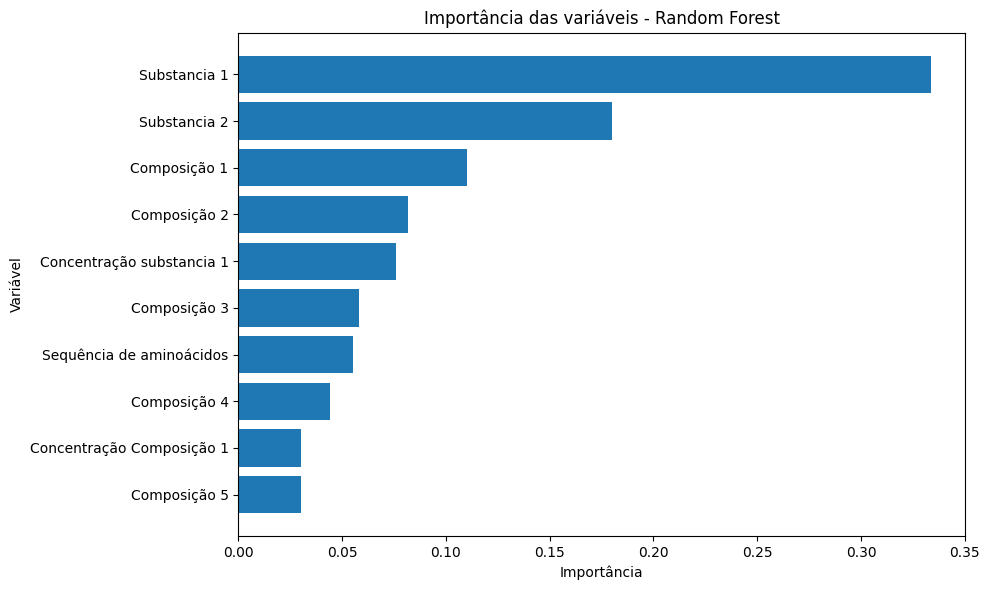

In [ ]:
#Esse é bom para mostrar quais informações mais influenciaram o Random Forest inicial.
plt.figure(figsize=(10, 6))
plt.barh(importancia_por_coluna["coluna_original"], importancia_por_coluna["importancia"])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Importância das variáveis - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/graficos/importancia_variaveis_random_forest.png", dpi=300)
plt.show()